# **Assignment 2**
## **Ridge Regression**

## **Importing Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

"from google.colab import drive\ndrive.mount('/content/drive')"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

## **Reading Data from the Drive**

In [ ]:
data = pd.read_csv('/content/drive/My Drive/Sem5/new_ml/a6/reg/train.csv')
data.describe()

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


## **Removing unwanted Features**

In [ ]:
data.drop('Name',axis=1,inplace=True)
data.drop('Customer ID',axis=1,inplace=True)
data.drop('Gender',axis=1,inplace=True)
data.drop('Age',axis=1,inplace=True)
data.drop('Property ID',axis=1,inplace=True)
data.drop('Expense Type 1',axis=1,inplace=True)
data.drop('Expense Type 2',axis=1,inplace=True)
data.drop('Type of Employment',axis=1,inplace=True)
data.drop('Has Active Credit Card',axis=1,inplace=True)
data.drop('Co-Applicant',axis=1,inplace=True)
data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.05,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05,4,Rural,119933.46,54607.18
1,4952.91,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91,2,Rural,54791.00,37469.98
2,988.19,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19,2,Urban,72440.58,36474.43
3,NaN,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,NaN,2,Semi-Urban,121441.51,56040.54
4,2614.77,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.55,1,2614.77,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.41,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.61,0,4969.41,4,Urban,111096.56,68992.11
29996,1606.88,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.41,0,1606.88,3,Urban,73453.94,46616.60
29997,NaN,Low,Working,Urban,81410.08,583.11,NaN,NaN,0,NaN,1,Rural,102108.02,61057.56
29998,2417.71,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.27,1,2417.71,4,Urban,168194.47,99766.87


## **Missing Values Imputation**

**1) Profession**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


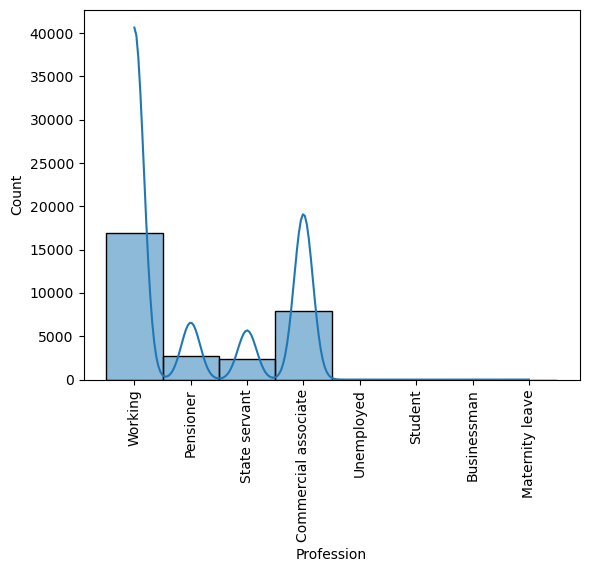

In [ ]:
sns.histplot(data['Profession'],kde='True')
plt.xticks(rotation=90)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


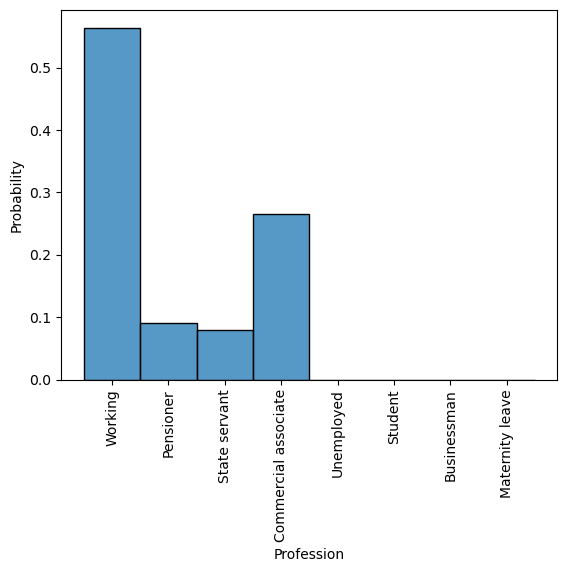

In [ ]:
sns.histplot(data['Profession'],stat='probability',discrete=True)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_numeric = data.select_dtypes(include='number')
corr_matrix = df_numeric.corr()
corr_matrix

,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Price,Loan Sanction Amount (USD)
Income (USD),1.000000,0.050371,0.055080,0.005170,0.012911,-0.002141,1.000000,0.009733,0.050679,0.038157
Loan Amount Request (USD),0.050371,1.000000,0.682248,0.040952,0.178260,0.000088,0.049976,0.003802,0.948350,0.726408
Current Loan Expenses (USD),0.055080,0.682248,1.000000,0.045300,0.114950,0.002767,0.054682,0.014812,0.648636,0.485070
Dependents,0.005170,0.040952,0.045300,1.000000,-0.090271,0.009108,0.005082,-0.009303,0.037302,0.009088
Credit Score,0.012911,0.178260,0.114950,-0.090271,1.000000,0.006647,0.012959,0.009116,0.170829,0.369450
No. of Defaults,-0.002141,0.000088,0.002767,0.009108,0.006647,1.000000,-0.002093,0.000477,0.001718,-0.004330
Property Age,1.000000,0.049976,0.054682,0.005082,0.012959,-0.002093,1.000000,0.009798,0.050306,0.037796
Property Type,0.009733,0.003802,0.014812,-0.009303,0.009116,0.000477,0.009798,1.000000,0.003279,0.001984
Property Price,0.050679,0.948350,0.648636,0.037302,0.170829,0.001718,0.050306,0.003279,1.000000,0.687181
Loan Sanction Amount (USD),0.038157,0.726408,0.485070,0.009088,0.369450,-0.004330,0.037796,0.001984,0.687181,1.000000


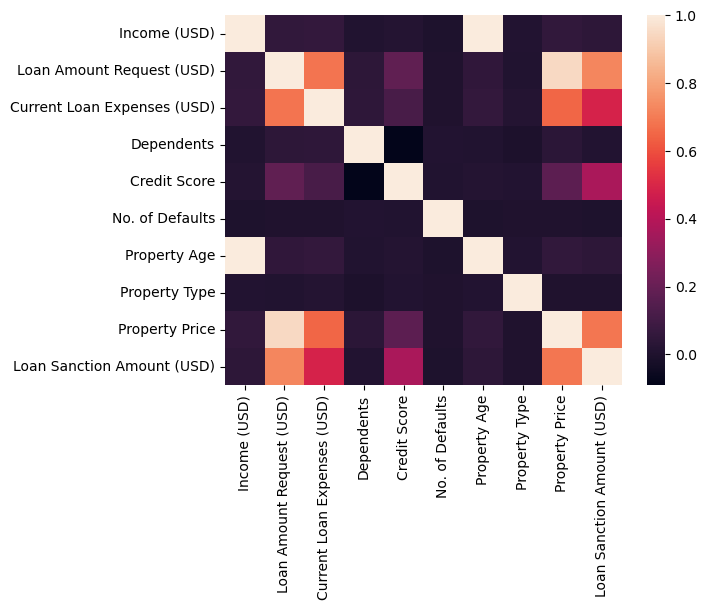

In [ ]:
sns.heatmap(corr_matrix)
plt.show()

**2) Property Age**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


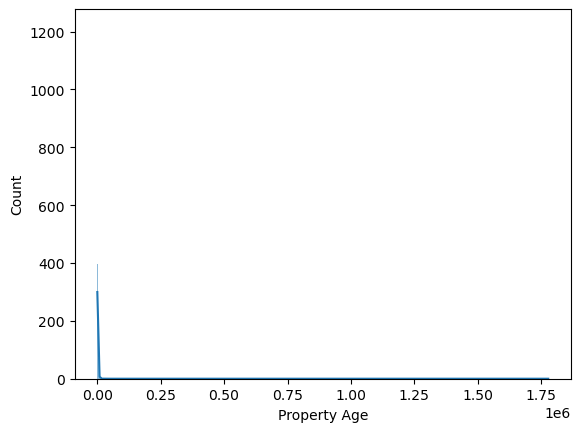

In [ ]:
sns.histplot(data['Property Age'],kde=True)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


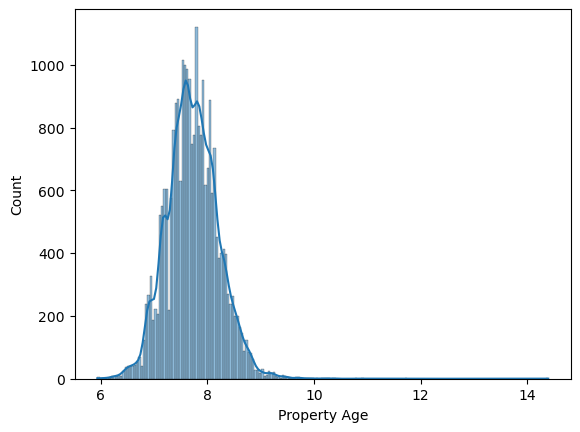

In [ ]:
sns.histplot(np.log1p(data['Property Age']),kde=True)
plt.show()

In [ ]:
prop_age_imputer = SimpleImputer(strategy='mean')
data['Property Age'] = prop_age_imputer.fit_transform(data[['Property Age']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.05,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.91,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91000,2,Rural,54791.00,37469.98
2,988.19,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19000,2,Urban,72440.58,36474.43
3,NaN,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.77,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.55,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.41,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.61,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.88,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.41,0,1606.88000,3,Urban,73453.94,46616.60
29997,NaN,Low,Working,Urban,81410.08,583.11,NaN,NaN,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.71,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.27,1,2417.71000,4,Urban,168194.47,99766.87


In [ ]:
data['Property Age'].mode()

0    2631.11944
Name: Property Age, dtype: float64

In [ ]:
data['Property Age'].value_counts()

Property Age
2631.11944    4850
2415.70000       4
1608.43000       4
2443.33000       3
2304.81000       3
              ... 
3149.78000       1
1410.24000       1
2012.66000       1
2269.79000       1
3068.24000       1
Name: count, Length: 24180, dtype: int64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


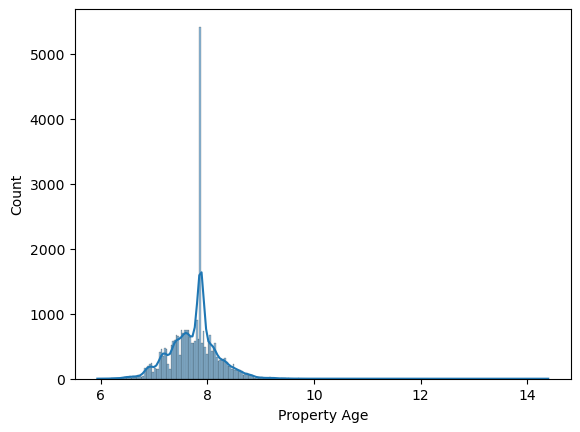

In [ ]:
sns.histplot(np.log1p(data['Property Age']),kde=True)
plt.show()

In [ ]:
missing_data = data.isnull().sum()
print(missing_data)

Income (USD)                   4576
Income Stability               1683
Profession                        0
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Property Age                      0
Property Type                     0
Property Location               356
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64


**3) Income(USD)**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Income (USD)', ylabel='Count'>

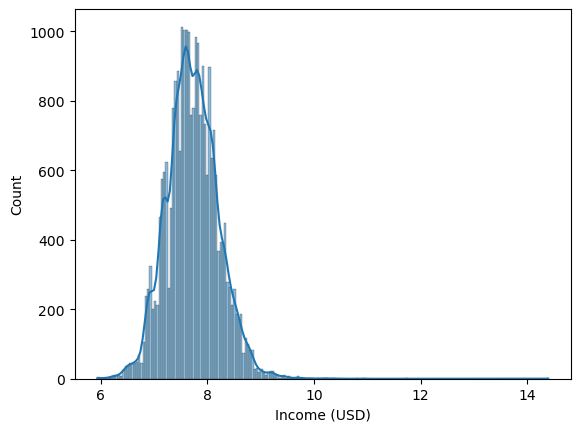

In [ ]:
sns.histplot(np.log1p(data['Income (USD)']),kde=True)

In [ ]:
income_imputer = SimpleImputer(strategy='mean')
data['Income (USD)'] = income_imputer.fit_transform(data[['Income (USD)']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.55,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.61,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.41,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,NaN,NaN,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.27,1,2417.71000,4,Urban,168194.47,99766.87


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Income (USD)', ylabel='Count'>

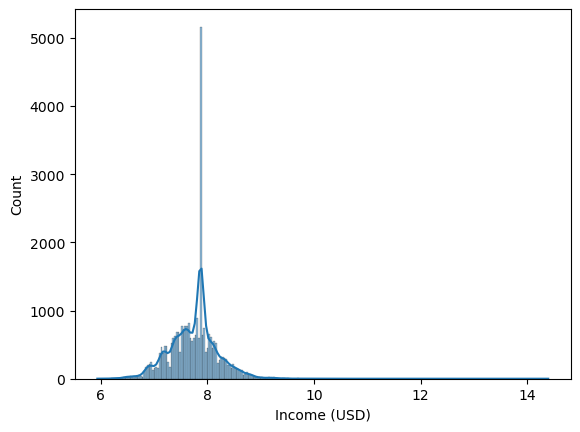

In [ ]:
sns.histplot(np.log1p(data['Income (USD)']),kde=True)

**4) Income Stability**

In [ ]:
income_stab_imputer = SimpleImputer(strategy='most_frequent')
data[['Income Stability']] = income_stab_imputer.fit_transform(data[['Income Stability']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.55,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.61,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.41,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,NaN,NaN,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.27,1,2417.71000,4,Urban,168194.47,99766.87


**5) Current Loan Expenses**

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Current Loan Expenses (USD)', ylabel='Count'>

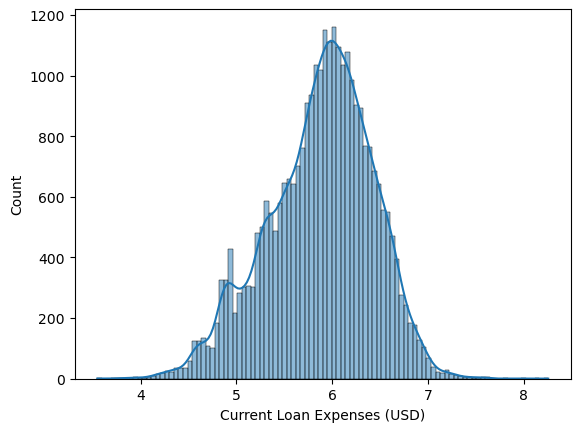

In [ ]:
sns.histplot(np.log1p(data['Current Loan Expenses (USD)']),kde=True)

In [ ]:
cur_loan_exp_imputer = SimpleImputer(strategy='mean')
data['Current Loan Expenses (USD)'] = cur_loan_exp_imputer.fit_transform(data[['Current Loan Expenses (USD)']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.55,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.61,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.41,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,NaN,NaN,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.27,1,2417.71000,4,Urban,168194.47,99766.87


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Current Loan Expenses (USD)', ylabel='Count'>

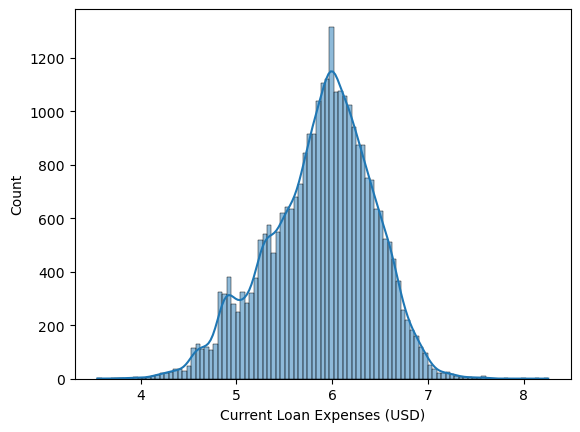

In [ ]:
sns.histplot(np.log1p(data['Current Loan Expenses (USD)']),kde=True)

**6) Credit Score**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Credit Score', ylabel='Count'>

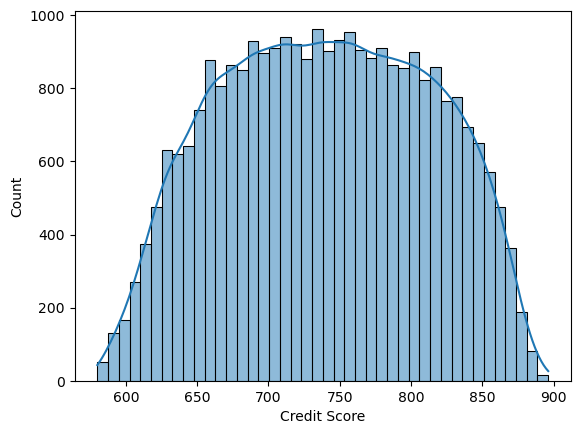

In [ ]:
sns.histplot((data['Credit Score']),kde=True)

In [ ]:
credit_score_imputer = SimpleImputer(strategy='mean')
data['Credit Score'] = credit_score_imputer.fit_transform(data[['Credit Score']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,NaN,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,NaN,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Credit Score', ylabel='Count'>

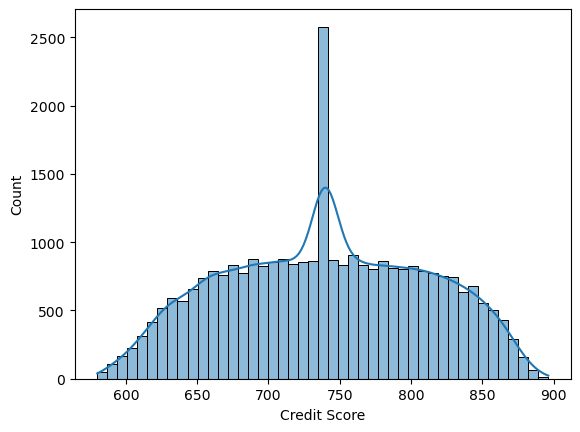

In [ ]:
sns.histplot((data['Credit Score']),kde=True)

**7) Dependents**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Dependents', ylabel='Count'>

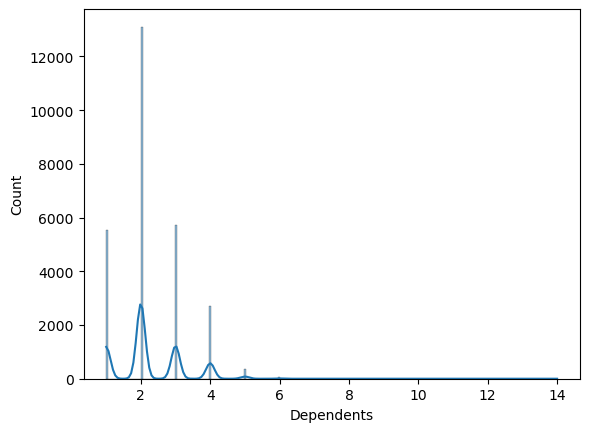

In [ ]:
sns.histplot((data['Dependents']),kde=True)

In [ ]:
dependents_imputer = SimpleImputer(strategy='median')
data['Dependents'] = dependents_imputer.fit_transform(data[['Dependents']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,2.0,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,2.0,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Dependents', ylabel='Count'>

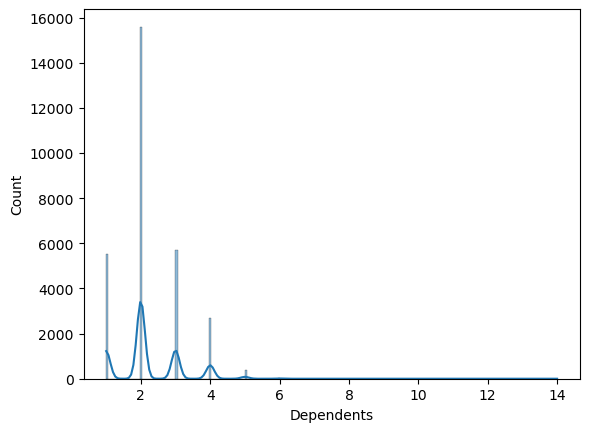

In [ ]:
sns.histplot((data['Dependents']),kde=True)

**8) Property Location**

In [ ]:
prop_loc_imputer = SimpleImputer(strategy='most_frequent')
data[['Property Location']] = prop_loc_imputer.fit_transform(data[['Property Location']])

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,2.0,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,2.0,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


**9) Loan Sanction Amount (USD)**

In [ ]:
data.dropna(subset=['Loan Sanction Amount (USD)'],inplace=True)

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,2.0,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,Low,Commercial associate,Urban,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,Low,Working,Semi-Urban,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,Low,Working,Urban,81410.08,583.11,2.0,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,Low,Working,Semi-Urban,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


In [ ]:
print(data.isnull().sum())

Income (USD)                   0
Income Stability               0
Profession                     0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Property Age                   0
Property Type                  0
Property Location              0
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64


In [ ]:
data.head()

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,Low,Working,Semi-Urban,72809.58,241.08,3.0,809.44,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,Low,Working,Semi-Urban,46837.47,495.81,1.0,780.40,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,High,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.15,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,High,Pensioner,Rural,80057.92,298.54,2.0,832.70,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,Low,Working,Semi-Urban,113858.89,491.41,2.0,745.55,1,2614.77000,4,Semi-Urban,208567.91,74008.28


## **Label Encoding**

In [ ]:
data['Property Location'].unique()

array(['Rural', 'Urban', 'Semi-Urban'], dtype=object)

**1) Income Stability**

In [ ]:
# Step 1: Calculate mean of target for each profession
target_mean = data.groupby('Income Stability')['Loan Sanction Amount (USD)'].mean()

# Step 2: Map the mean back to the 'Profession' column
data['Income Stability'] = data['Income Stability'].map(target_mean)

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,47047.312790,Working,Semi-Urban,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,47047.312790,Working,Semi-Urban,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,54066.256399,Pensioner,Semi-Urban,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,54066.256399,Pensioner,Rural,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,47047.312790,Working,Semi-Urban,113858.89,491.41,2.0,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,47047.312790,Commercial associate,Urban,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,47047.312790,Working,Semi-Urban,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,47047.312790,Working,Urban,81410.08,583.11,2.0,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,47047.312790,Working,Semi-Urban,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


**2) Location**

In [ ]:
# Step 1: Calculate mean of target for each profession
target_mean = data.groupby('Location')['Loan Sanction Amount (USD)'].mean()

# Step 2: Map the mean back to the 'Profession' column
data['Location'] = data['Location'].map(target_mean)

data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,47047.312790,Working,46140.487738,72809.58,241.08,3.0,809.440000,0,1933.05000,4,Rural,119933.46,54607.18
1,4952.910000,47047.312790,Working,46140.487738,46837.47,495.81,1.0,780.400000,0,4952.91000,2,Rural,54791.00,37469.98
2,988.190000,54066.256399,Pensioner,46140.487738,45593.04,171.95,1.0,833.150000,0,988.19000,2,Urban,72440.58,36474.43
3,2630.574417,54066.256399,Pensioner,43491.369250,80057.92,298.54,2.0,832.700000,1,2631.11944,2,Semi-Urban,121441.51,56040.54
4,2614.770000,47047.312790,Working,46140.487738,113858.89,491.41,2.0,745.550000,1,2614.77000,4,Semi-Urban,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,47047.312790,Commercial associate,65317.754861,76657.90,722.34,2.0,869.610000,0,4969.41000,4,Urban,111096.56,68992.11
29996,1606.880000,47047.312790,Working,46140.487738,66595.14,253.04,3.0,729.410000,0,1606.88000,3,Urban,73453.94,46616.60
29997,2630.574417,47047.312790,Working,65317.754861,81410.08,583.11,2.0,739.885381,0,2631.11944,1,Rural,102108.02,61057.56
29998,2417.710000,47047.312790,Working,46140.487738,142524.10,378.29,3.0,677.270000,1,2417.71000,4,Urban,168194.47,99766.87


**3) Property Location**

In [ ]:
# Step 1: Calculate mean of target for each profession
target_mean = data.groupby('Property Location')['Loan Sanction Amount (USD)'].mean()

# Step 2: Map the mean back to the 'Profession' column
data['Property Location'] = data['Property Location'].map(target_mean)

data

#data = pd.get_dummies(data,columns=['Location','Property Location'],drop_first=True)
#data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,47047.312790,Working,46140.487738,72809.58,241.08,3.0,809.440000,0,1933.05000,4,47249.940879,119933.46,54607.18
1,4952.910000,47047.312790,Working,46140.487738,46837.47,495.81,1.0,780.400000,0,4952.91000,2,47249.940879,54791.00,37469.98
2,988.190000,54066.256399,Pensioner,46140.487738,45593.04,171.95,1.0,833.150000,0,988.19000,2,48124.183177,72440.58,36474.43
3,2630.574417,54066.256399,Pensioner,43491.369250,80057.92,298.54,2.0,832.700000,1,2631.11944,2,47614.521665,121441.51,56040.54
4,2614.770000,47047.312790,Working,46140.487738,113858.89,491.41,2.0,745.550000,1,2614.77000,4,47614.521665,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,47047.312790,Commercial associate,65317.754861,76657.90,722.34,2.0,869.610000,0,4969.41000,4,48124.183177,111096.56,68992.11
29996,1606.880000,47047.312790,Working,46140.487738,66595.14,253.04,3.0,729.410000,0,1606.88000,3,48124.183177,73453.94,46616.60
29997,2630.574417,47047.312790,Working,65317.754861,81410.08,583.11,2.0,739.885381,0,2631.11944,1,47249.940879,102108.02,61057.56
29998,2417.710000,47047.312790,Working,46140.487738,142524.10,378.29,3.0,677.270000,1,2417.71000,4,48124.183177,168194.47,99766.87


**4) Profession**

In [ ]:
# Step 1: Calculate mean of target for each profession
target_mean = data.groupby('Profession')['Loan Sanction Amount (USD)'].mean()

# Step 2: Map the mean back to the 'Profession' column
data['Profession'] = data['Profession'].map(target_mean)

In [ ]:
data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,47047.312790,43372.179038,46140.487738,72809.58,241.08,3.0,809.440000,0,1933.05000,4,47249.940879,119933.46,54607.18
1,4952.910000,47047.312790,43372.179038,46140.487738,46837.47,495.81,1.0,780.400000,0,4952.91000,2,47249.940879,54791.00,37469.98
2,988.190000,54066.256399,54825.847763,46140.487738,45593.04,171.95,1.0,833.150000,0,988.19000,2,48124.183177,72440.58,36474.43
3,2630.574417,54066.256399,54825.847763,43491.369250,80057.92,298.54,2.0,832.700000,1,2631.11944,2,47614.521665,121441.51,56040.54
4,2614.770000,47047.312790,43372.179038,46140.487738,113858.89,491.41,2.0,745.550000,1,2614.77000,4,47614.521665,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,47047.312790,52507.008598,65317.754861,76657.90,722.34,2.0,869.610000,0,4969.41000,4,48124.183177,111096.56,68992.11
29996,1606.880000,47047.312790,43372.179038,46140.487738,66595.14,253.04,3.0,729.410000,0,1606.88000,3,48124.183177,73453.94,46616.60
29997,2630.574417,47047.312790,43372.179038,65317.754861,81410.08,583.11,2.0,739.885381,0,2631.11944,1,47249.940879,102108.02,61057.56
29998,2417.710000,47047.312790,43372.179038,46140.487738,142524.10,378.29,3.0,677.270000,1,2417.71000,4,48124.183177,168194.47,99766.87


## **Outlier Treatment**

In [ ]:
data.corr()

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
Income (USD),1.000000,-0.012035,0.006236,0.030755,0.045949,0.050435,0.004925,0.011682,-0.001942,0.999892,0.008888,-0.000740,0.046295,0.034997
Income Stability,-0.012035,1.000000,0.444866,-0.020506,-0.014300,-0.040609,-0.156072,0.273490,0.003743,-0.011927,0.008365,0.006426,-0.012172,0.040761
Profession,0.006236,0.444866,1.000000,0.148594,0.078043,0.058724,-0.090838,0.213280,-0.003288,0.006128,-0.000346,0.009258,0.077914,0.102136
Location,0.030755,-0.020506,0.148594,1.000000,0.142466,0.164547,-0.021619,0.125190,-0.003960,0.030217,-0.004466,0.000793,0.135333,0.126064
Loan Amount Request (USD),0.045949,-0.014300,0.078043,0.142466,1.000000,0.681192,0.039133,0.172441,-0.000114,0.045377,0.004043,0.006201,0.948553,0.726408
Current Loan Expenses (USD),0.050435,-0.040609,0.058724,0.164547,0.681192,1.000000,0.042979,0.110906,0.001943,0.049766,0.015184,-0.000832,0.647941,0.483733
Dependents,0.004925,-0.156072,-0.090838,-0.021619,0.039133,0.042979,1.000000,-0.083326,0.007991,0.004809,-0.008972,-0.001419,0.035927,0.004788
Credit Score,0.011682,0.273490,0.213280,0.125190,0.172441,0.110906,-0.083326,1.000000,0.006858,0.011666,0.008029,0.003164,0.165141,0.359709
No. of Defaults,-0.001942,0.003743,-0.003288,-0.003960,-0.000114,0.001943,0.007991,0.006858,1.000000,-0.001879,0.000089,0.004337,0.001622,-0.004330
Property Age,0.999892,-0.011927,0.006128,0.030217,0.045377,0.049766,0.004809,0.011666,-0.001879,1.000000,0.008912,-0.000707,0.045746,0.034493


In [ ]:
data

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price,Loan Sanction Amount (USD)
0,1933.050000,47047.312790,43372.179038,46140.487738,72809.58,241.08,3.0,809.440000,0,1933.05000,4,47249.940879,119933.46,54607.18
1,4952.910000,47047.312790,43372.179038,46140.487738,46837.47,495.81,1.0,780.400000,0,4952.91000,2,47249.940879,54791.00,37469.98
2,988.190000,54066.256399,54825.847763,46140.487738,45593.04,171.95,1.0,833.150000,0,988.19000,2,48124.183177,72440.58,36474.43
3,2630.574417,54066.256399,54825.847763,43491.369250,80057.92,298.54,2.0,832.700000,1,2631.11944,2,47614.521665,121441.51,56040.54
4,2614.770000,47047.312790,43372.179038,46140.487738,113858.89,491.41,2.0,745.550000,1,2614.77000,4,47614.521665,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4969.410000,47047.312790,52507.008598,65317.754861,76657.90,722.34,2.0,869.610000,0,4969.41000,4,48124.183177,111096.56,68992.11
29996,1606.880000,47047.312790,43372.179038,46140.487738,66595.14,253.04,3.0,729.410000,0,1606.88000,3,48124.183177,73453.94,46616.60
29997,2630.574417,47047.312790,43372.179038,65317.754861,81410.08,583.11,2.0,739.885381,0,2631.11944,1,47249.940879,102108.02,61057.56
29998,2417.710000,47047.312790,43372.179038,46140.487738,142524.10,378.29,3.0,677.270000,1,2417.71000,4,48124.183177,168194.47,99766.87


In [ ]:
data.columns

Index(['Income (USD)', 'Income Stability', 'Profession', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age',
       'Property Type', 'Property Location', 'Property Price',
       'Loan Sanction Amount (USD)'],
      dtype='object')

In [ ]:
target = data[['Loan Sanction Amount (USD)']]
data.drop(columns=['Loan Sanction Amount (USD)'],inplace=True)

In [ ]:
x = data
y = target

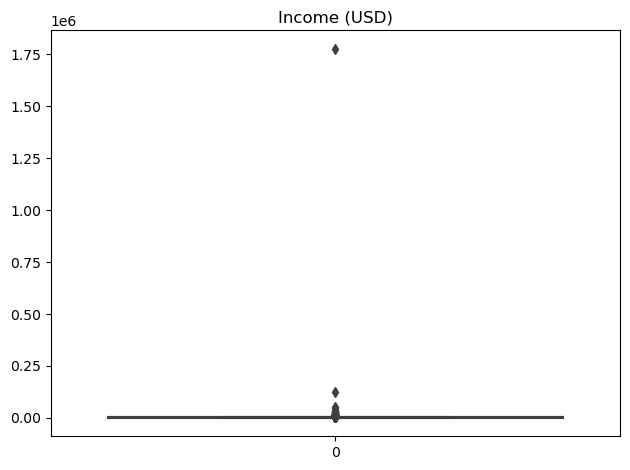

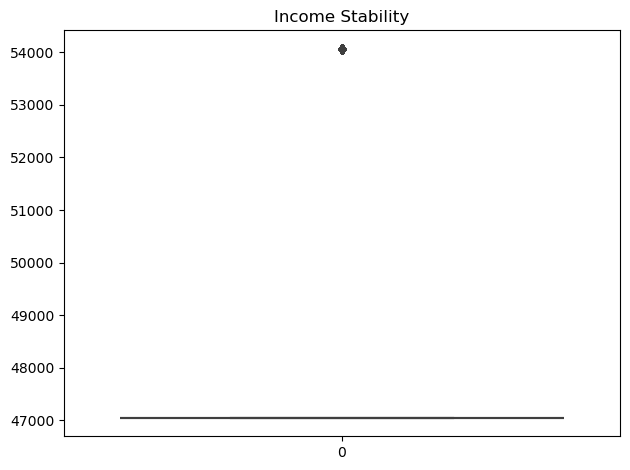

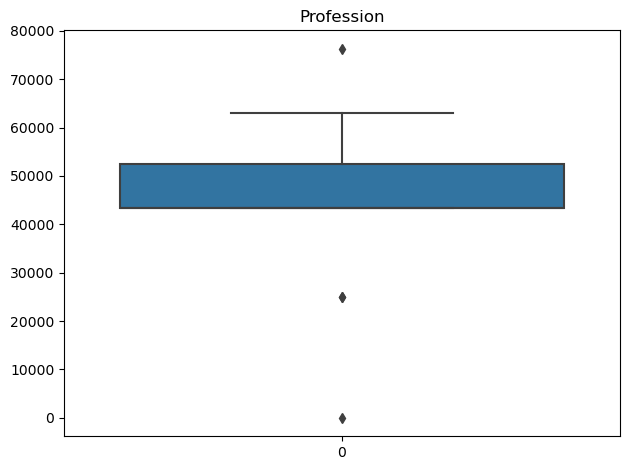

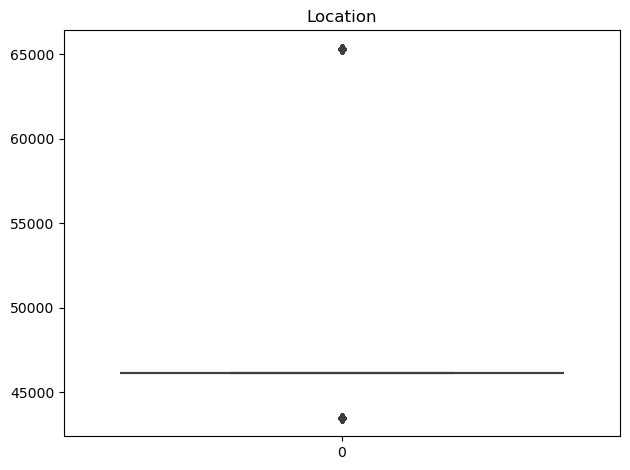

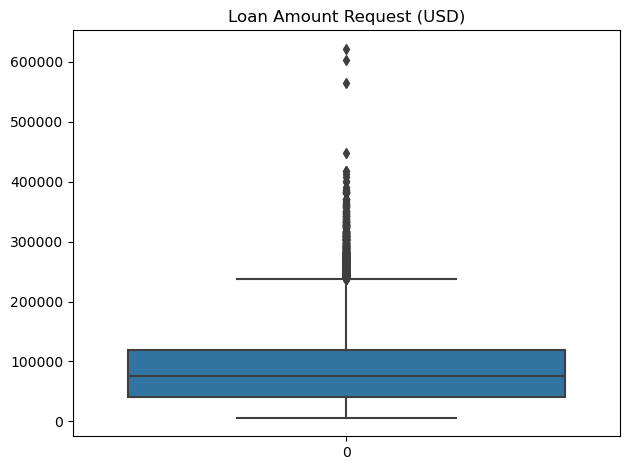

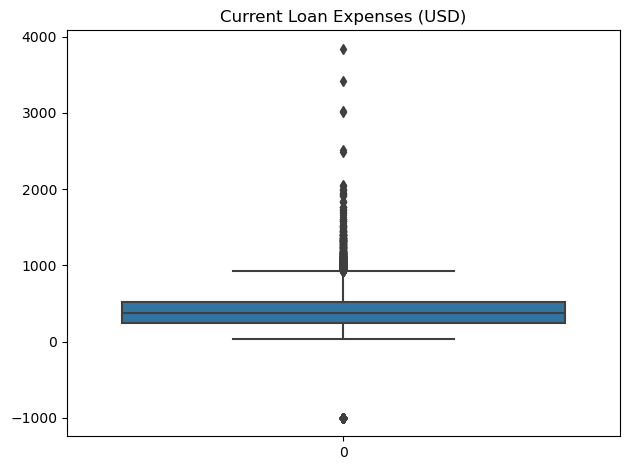

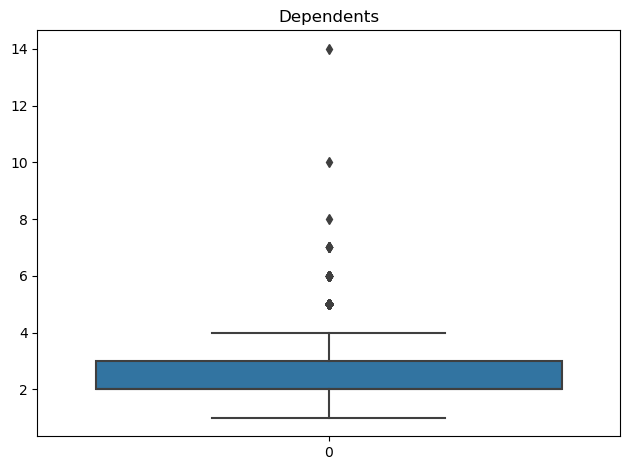

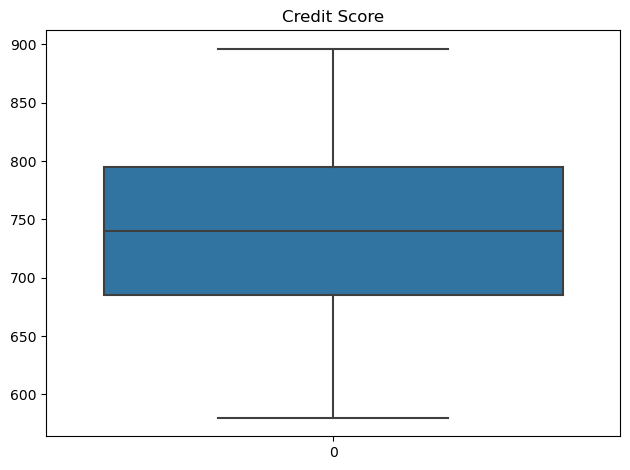

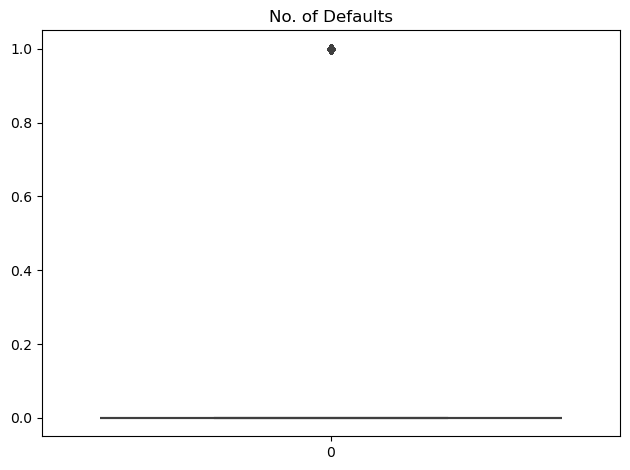

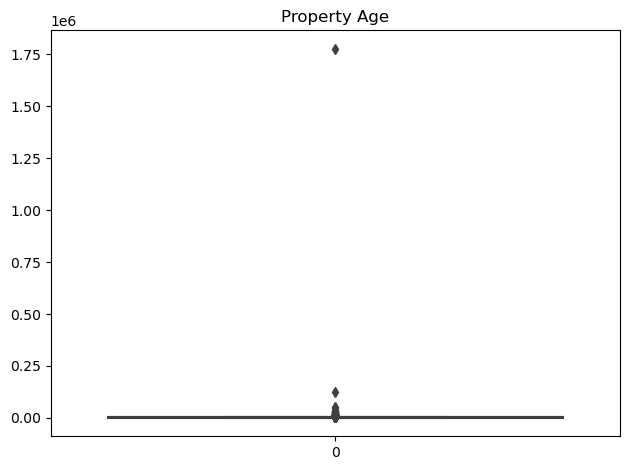

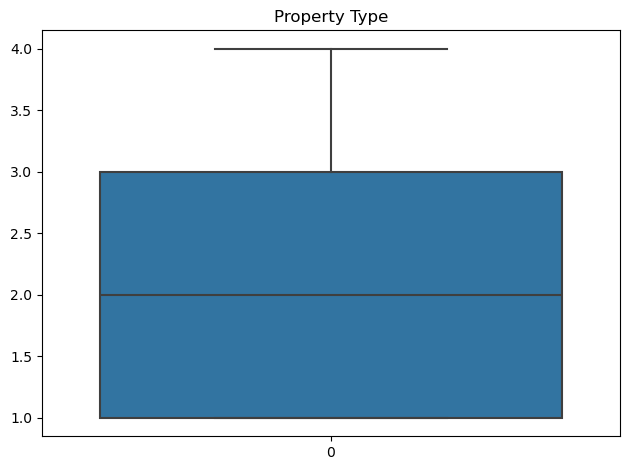

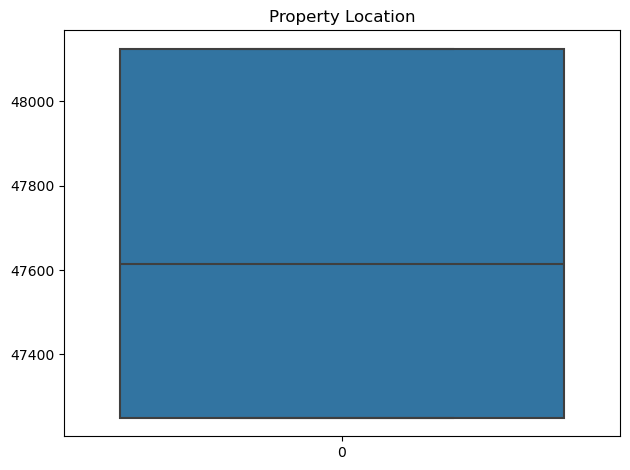

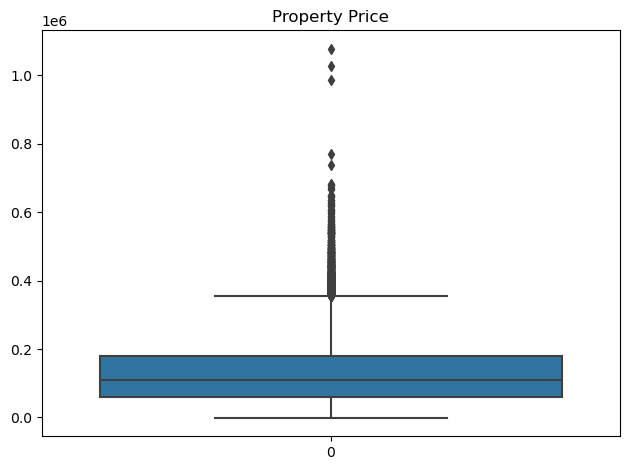

In [ ]:
for col in x.columns:
  sns.boxplot(x[col])
  plt.title(col)
  plt.tight_layout()
  plt.show()

In [ ]:
outlier_column = ['Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'Property Age', 'Property Type','Property Location',
       'Property Price','Profession','Location','Income Stability']


for col in outlier_column:
  Q1 = x[col].quantile(0.25)
  Q3 = x[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  x[col] = x[col].clip(low, high)


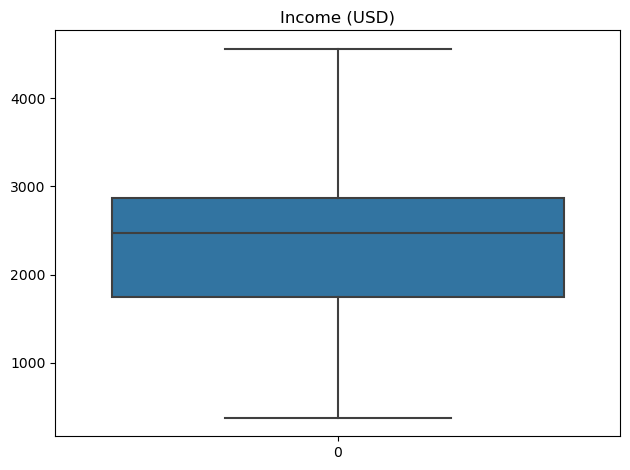

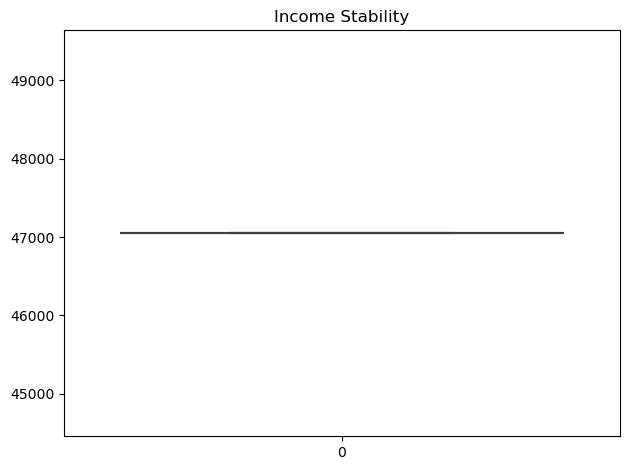

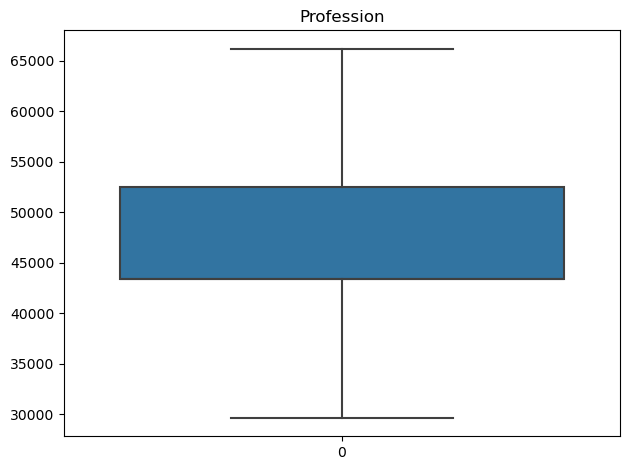

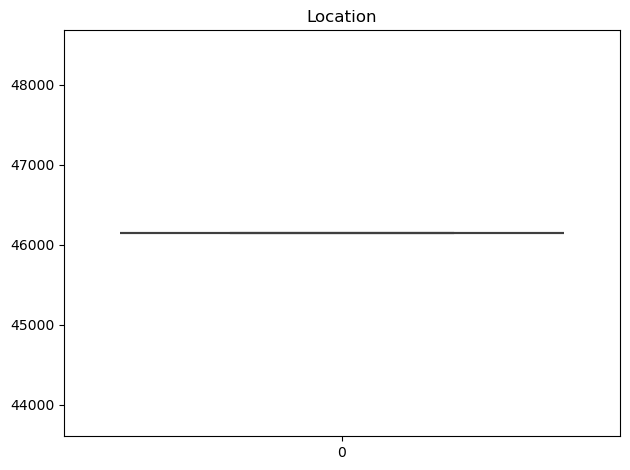

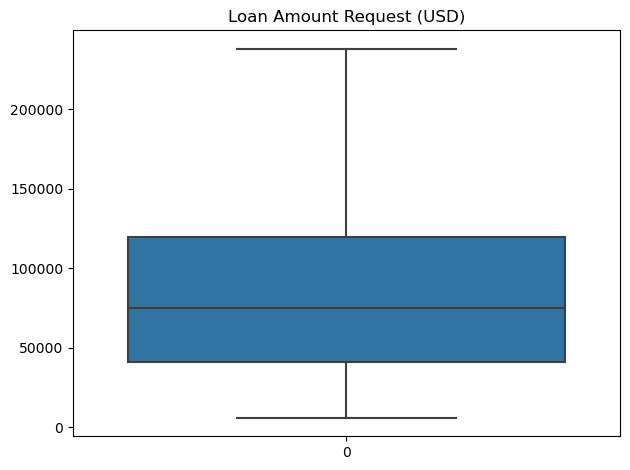

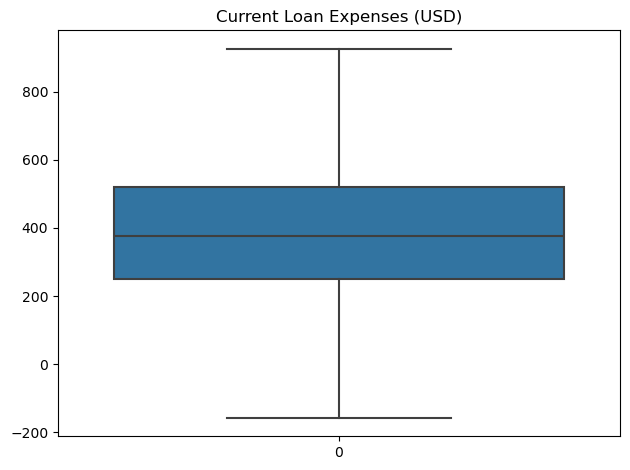

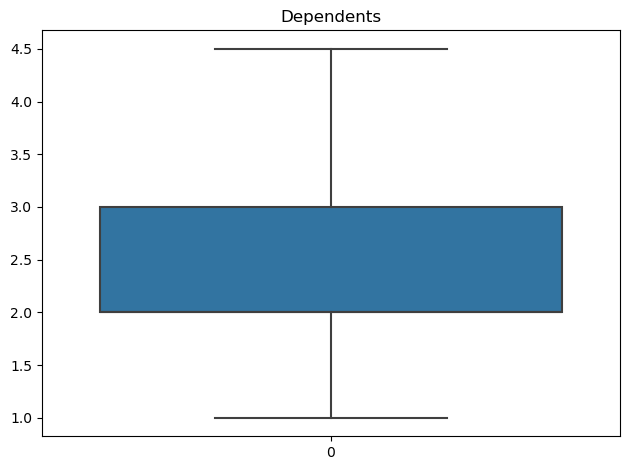

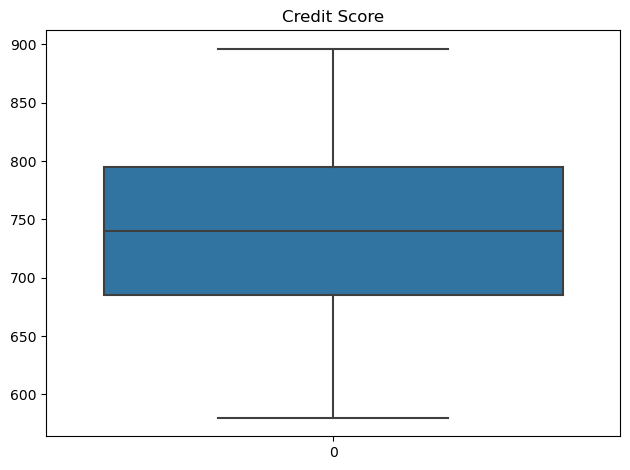

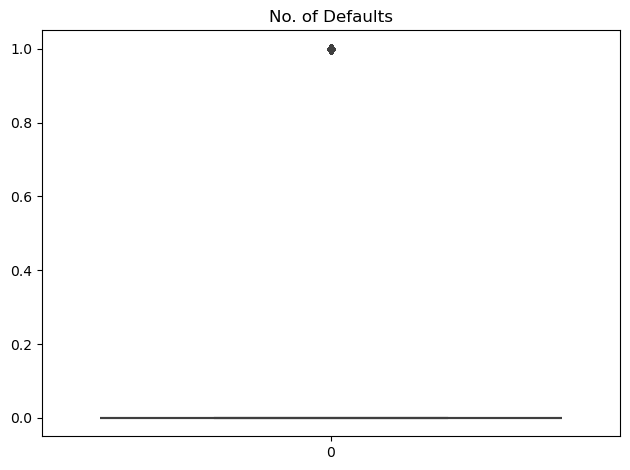

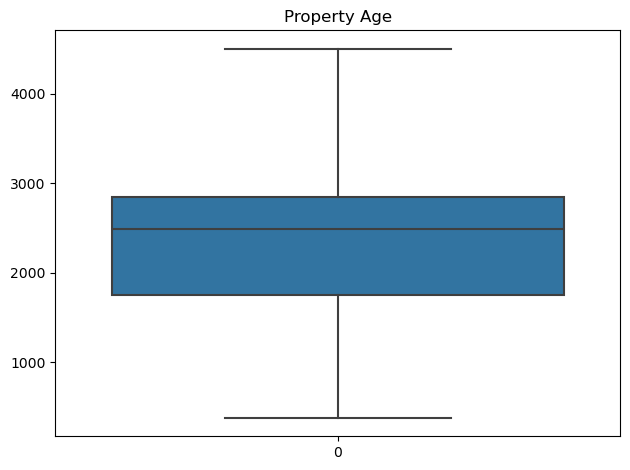

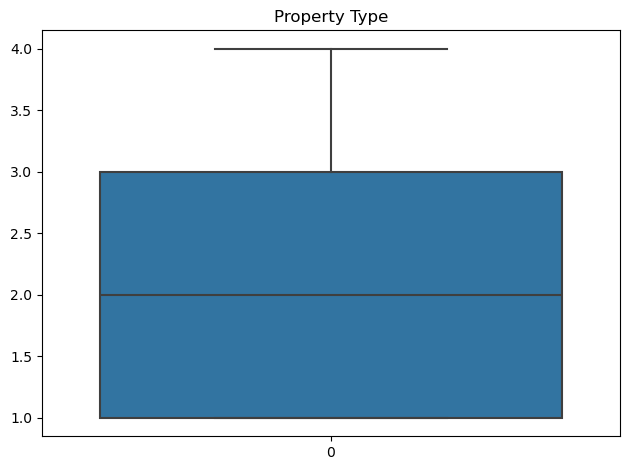

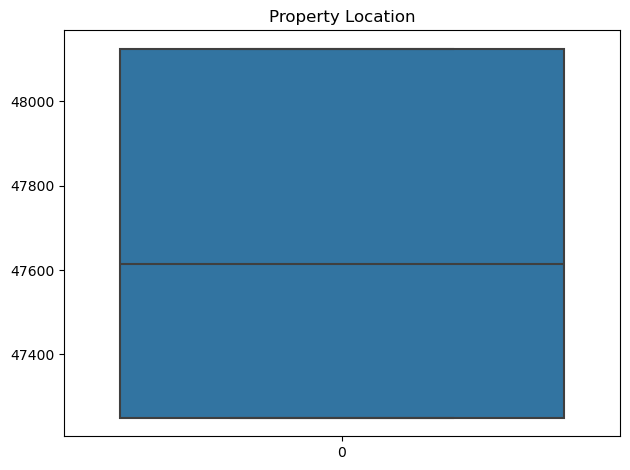

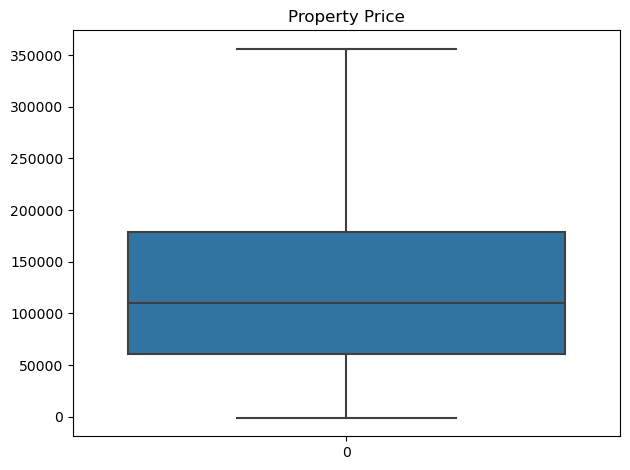

In [ ]:
for col in x.columns:
  sns.boxplot(x[col])
  plt.title(col)
  plt.tight_layout()
  plt.show()

In [ ]:
x.columns

Index(['Income (USD)', 'Income Stability', 'Profession', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age',
       'Property Type', 'Property Location', 'Property Price'],
      dtype='object')

In [ ]:
x.head()

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price
0,1933.050000,47047.31279,43372.179038,46140.487738,72809.58,241.08,3.0,809.44,0,1933.05000,4,47249.940879,119933.46
1,4561.072500,47047.31279,43372.179038,46140.487738,46837.47,495.81,1.0,780.40,0,4503.23375,2,47249.940879,54791.00
2,988.190000,47047.31279,54825.847763,46140.487738,45593.04,171.95,1.0,833.15,0,988.19000,2,48124.183177,72440.58
3,2630.574417,47047.31279,54825.847763,46140.487738,80057.92,298.54,2.0,832.70,1,2631.11944,2,47614.521665,121441.51
4,2614.770000,47047.31279,43372.179038,46140.487738,113858.89,491.41,2.0,745.55,1,2614.77000,4,47614.521665,208567.91


## **Standarization or Normalization**

In [ ]:
scaler = StandardScaler()

numeric_cols = ['Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'Property Age', 'Property Type','Property Location',
       'Property Price','Profession','Location','Income Stability']

x[numeric_cols] = scaler.fit_transform(x[numeric_cols])

In [ ]:
x.head()

,Income (USD),Income Stability,Profession,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Property Location,Property Price
0,-0.556419,-1.455192e-11,-0.870340,7.275958e-12,-0.266582,-0.787101,0.881368,0.992788,0,-0.562482,1.376616,-1.137747,-0.112344
1,2.202677,-1.455192e-11,-0.870340,7.275958e-12,-0.729023,0.463085,-1.385880,0.578465,0,2.173317,-0.411213,-1.137747,-0.866411
2,-1.548404,-1.455192e-11,1.459785,7.275958e-12,-0.751180,-1.126384,-1.385880,1.331067,0,-1.568226,-0.411213,1.352647,-0.662106
3,0.175895,-1.455192e-11,1.459785,7.275958e-12,-0.137523,-0.505094,-0.252256,1.324646,1,0.180569,-0.411213,-0.099191,-0.094887
4,0.159302,-1.455192e-11,-0.870340,7.275958e-12,0.464313,0.441490,-0.252256,0.081249,1,0.163166,1.376616,-0.099191,0.913660


In [ ]:
y

,Loan Sanction Amount (USD)
0,54607.18
1,37469.98
2,36474.43
3,56040.54
4,74008.28
...,...
29995,68992.11
29996,46616.60
29997,61057.56
29998,99766.87


## **Model Training**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val   = train_test_split(x_train,y_train,test_size=0.4,random_state=42)

print(x_train.shape,x_test.shape)
print(x_val.shape,y_val.shape)
print(y_train.shape,y_test.shape)

(14236, 13) (5932, 13)
(9492, 13) (9492, 1)
(14236, 1) (5932, 1)


In [ ]:
lr_model = Ridge()
lr_model.fit(x_train,y_train)

y_pre_train = lr_model.predict(x_train)
print(lr_model.get_params())

{'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


**Training Performance Metrics**

In [ ]:
print("Training Accuracy :",lr_model.score(x_train,y_train)*100)

sse = np.sum((y_train.values - y_pre_train)**2)
print("\nSum of Squared Error for Training data :",sse)

mae = mean_absolute_error(y_train,y_pre_train)
print("\nMean Absolute Error :",mae)

mse = mean_squared_error(y_train,y_pre_train)
print("\nMean Squared Error :",mse)

r2 = r2_score(y_train,y_pre_train)
print("\nR-squared (R²) For Training :",r2)

Training Accuracy : 57.03575601753189

Sum of Squared Error for Training data : 14019071747938.531

Mean Absolute Error : 21507.798087840463

Mean Squared Error : 984761994.0951483

R-squared (R²) For Training : 0.5703575601753189


In [ ]:
n = x.shape[0]
p = x.shape[1]

adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

print("Adjusted (R²) For Training :",adjusted_r2)

Adjusted (R²) For Training : 0.5701691586466904


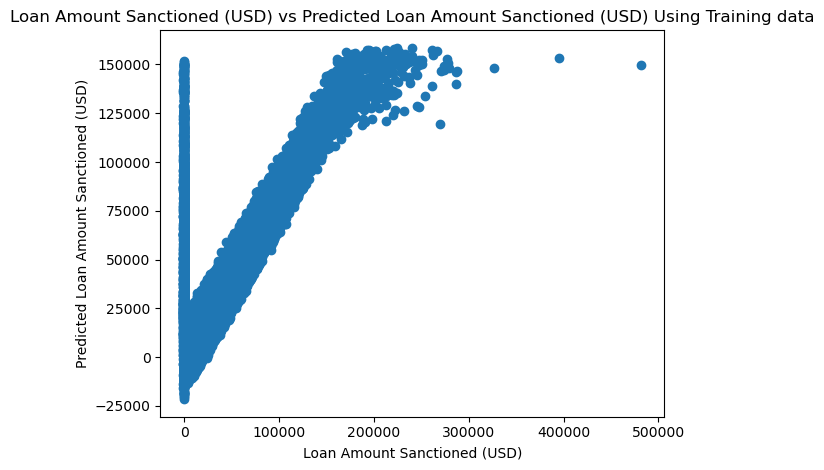

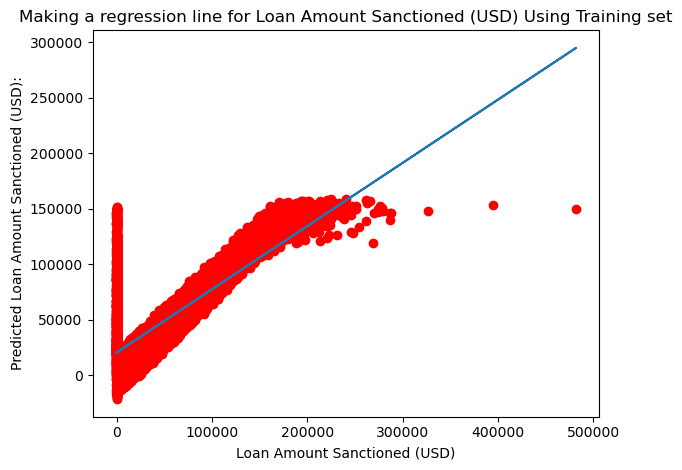

In [ ]:
def slope_intercept(x_val,y_val):
  x=np.array(x_val)
  y=np.array(y_val)
  m=(((np.mean(x)*np.mean(y)) - np.mean(x*y)) / ((np.mean(x)*np.mean(x)) -np.mean(x*x)))
  m=round(m,2)
  b=(np.mean(y) - np.mean(x)*m)
  b=round(b,2)
  #print("Slope :",m,"\tIntercept :",b)
  return m,b


plt.scatter(y_train,y_pre_train)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD)")
plt.title("Loan Amount Sanctioned (USD) vs Predicted Loan Amount Sanctioned (USD) Using Training data")
plt.tight_layout()
plt.show()
print()

m,b=slope_intercept(y_train, y_pre_train)
reg_line=[(m*x)+b for x in y_train.values]
plt.scatter(y_train,y_pre_train,color="red")
plt.plot(y_train,reg_line)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD):")
plt.title("Making a regression line for Loan Amount Sanctioned (USD) Using Training set")
plt.tight_layout()
plt.show()
print()

In [ ]:
coefficients = pd.Series(lr_model.coef_.flatten(), index=x.columns)
print(coefficients.sort_values(ascending=False))

Loan Amount Request (USD)      34635.783636
Credit Score                   11656.255351
Income (USD)                    2422.742201
Dependents                       199.155374
Property Location                135.458774
Income Stability                   0.000000
Location                           0.000000
Profession                       -45.031397
Property Type                   -198.333344
Current Loan Expenses (USD)     -803.464827
No. of Defaults                -1045.564711
Property Price                 -1510.835800
Property Age                   -2593.857299
dtype: float64


In [ ]:
print("Train R2:", r2_score(y_train, y_pre_train))

Train R2: 0.5703575601753189


In [ ]:
y_pre_test = lr_model.predict(x_test)

## **Model Testing**

In [ ]:
print("Testing Accuracy :",lr_model.score(x_test,y_test)*100)

sse = np.sum((y_test.values - y_pre_test)**2)
print("\nSum of Squared Error for Training data :",sse)

mae = mean_absolute_error(y_test,y_pre_test)
print("\nMean Absolute Error :",mae)

mse = mean_squared_error(y_test,y_pre_test)
print("\nMean Squared Error :",mse)

rmse = np.sqrt(mse)
print("\nRoot Mean Squared Error :",rmse)

r2 = r2_score(y_test,y_pre_test)
print("\nR-squared (R²) For Testing :",r2)

Testing Accuracy : 55.41581813373533

Sum of Squared Error for Training data : 6002949185984.754

Mean Absolute Error : 21597.792910513952

Mean Squared Error : 1011960415.7088257

Root Mean Squared Error : 31811.3252743237

R-squared (R²) For Testing : 0.5541581813373533


In [ ]:
n = x.shape[0]
p = x.shape[1]

adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

In [ ]:
print("Adjusted (R²) For Testing :",adjusted_r2)

Adjusted (R²) For Testing : 0.5539626762559725


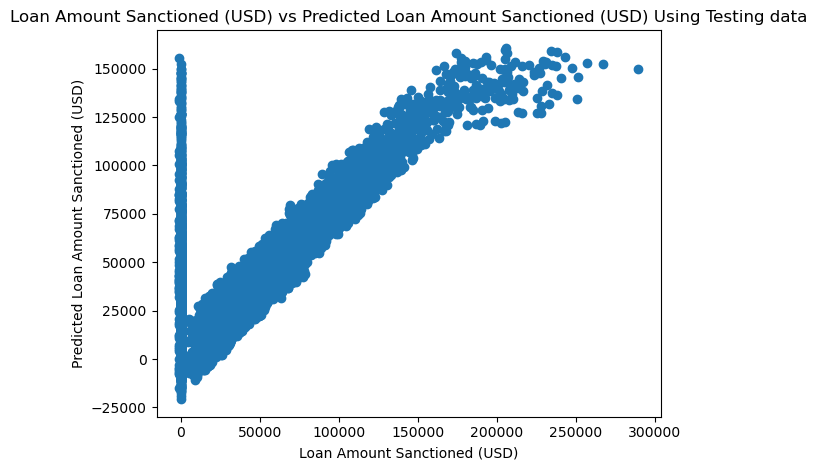

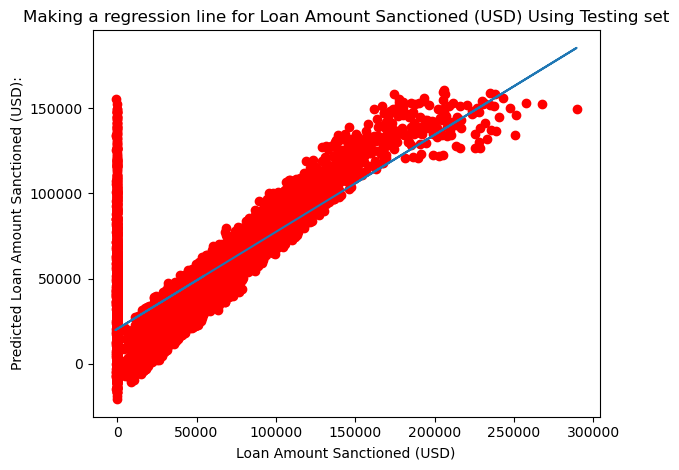

In [ ]:
def slope_intercept(x_val,y_val):
  x=np.array(x_val)
  y=np.array(y_val)
  m=(((np.mean(x)*np.mean(y)) - np.mean(x*y)) / ((np.mean(x)*np.mean(x)) -np.mean(x*x)))
  m=round(m,2)
  b=(np.mean(y) - np.mean(x)*m)
  b=round(b,2)
  #print("Slope :",m,"\tIntercept :",b)
  return m,b


plt.scatter(y_test,y_pre_test)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD)")
plt.title("Loan Amount Sanctioned (USD) vs Predicted Loan Amount Sanctioned (USD) Using Testing data")
plt.tight_layout()
plt.show()
print()

m,b=slope_intercept(y_test, y_pre_test)
reg_line=[(m*x)+b for x in y_test.values]
plt.scatter(y_test,y_pre_test,color="red")
plt.plot(y_test,reg_line)
plt.xlabel("Loan Amount Sanctioned (USD)")
plt.ylabel("Predicted Loan Amount Sanctioned (USD):")
plt.title("Making a regression line for Loan Amount Sanctioned (USD) Using Testing set")
plt.tight_layout()
#plt.savefig('/content/drive/My Drive/Sem5/ml/a2/residual_plot.png')
plt.show()
print()

## **Cross Validation Using KFold**

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge()

mse_scores = []
mae_scores = []
sse_scores = []
rmse_scores = []
r2_scores = []
adjusted_r2_scores = []


for train_index, test_index in kf.split(x):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    sse = np.sum((y_test.values - y_pred)**2)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

    mse_scores.append(mse)
    sse_scores.append(sse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    adjusted_r2_scores.append(adjusted_r2)

df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'mse_scores': mse_scores,
    'mae_scores': mae_scores,
    'sse_scores': sse_scores,
    'rmse_scores': rmse_scores,
    'r2_scores': r2_scores,
    'adjusted_r2_scores': adjusted_r2_scores
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'mse_scores': np.mean(mse_scores),
    'mae_scores': np.mean(mae_scores),
    'sse_scores': np.mean(sse_scores),
    'rmse_scores': np.mean(rmse_scores),
    'r2_scores': np.mean(r2_scores),
    'adjusted_r2_scores': np.mean(adjusted_r2_scores)
}])

df = pd.concat([df, mean_row], ignore_index=True)

In [ ]:
df

,KFold,mse_scores,mae_scores,sse_scores,rmse_scores,r2_scores,adjusted_r2_scores
0,1,1012665003.87149,21582.49969,6007128802965.66992,31822.39783,0.55385,0.55365
1,2,989596431.46971,21616.82436,5870286031478.31250,31457.85167,0.56381,0.56362
2,3,974366743.04945,21293.15606,5779943519769.34570,31214.84812,0.57797,0.57778
3,4,964103888.70691,21563.05283,5719064267809.40137,31050.02236,0.60105,0.60088
4,5,1032575241.66020,21784.09943,6125236333528.29492,32133.70881,0.56278,0.56259
5,Mean,994661461.75155,21567.92647,5900331791110.20508,31535.76576,0.57189,0.57170


In [ ]:
pd.set_option('display.float_format', '{:.5f}'.format)